In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from glob import glob
import os
import yaml

import warnings
warnings.filterwarnings('ignore')

In [2]:
from airquality import datamodules as datamodules

coi_map = {
    'NO$_2$ (ppb)': 8,
    'SO$_2$ (ppb)': 7,
    'CO (ppm)': 6,
    'PM$_{2.5}$ ($\mu$g/m$^3$)': 5,
    'PM$_{10}$ ($\mu$g/m$^3$)': 4,
    'Temperature ($^{\circ}$C)': 3,
    'Relative Humidity (%)': 2,
    'Precipitation (mm)': 1,
    'COI (%)': 0,
}

coi = datamodules.make('airquality_coi_daily')
coi.setup('none')

svi_map = {
    'NO$_2$ (ppb)': 8,
    'SO$_2$ (ppb)': 7,
    'CO (ppm)': 6,
    'PM$_{2.5}$ ($\mu$g/m$^3$)': 5,
    'PM$_{10}$ ($\mu$g/m$^3$)': 4,
    'Temperature ($^{\circ}$C)': 3,
    'Relative Humidity (%)': 2,
    'Precipitation (mm)': 1,
    'SVI (%)': 0,
}

svi = datamodules.make('airquality_svi_daily')
svi.setup('none')

In [3]:
from airquality.analysis.plotting import plot_effect, labels_map
from airquality.datamodules.preprocessing.prepare_analysis import prepare_outcomes

def get_trial_iqr(path):
    iqr_df = []
    for root, dirs, files in os.walk(path):
        if 'interquartile_range.csv' in files:
            iqr_df.append(pd.read_csv(os.path.join(root, 'interquartile_range.csv'), index_col=0))
    iqr_df = pd.concat(iqr_df)
    iqr_df = iqr_df.reset_index().rename({'index': 'parameter', '0': 'iqr'}, axis=1)
    iqr_df = iqr_df.groupby('parameter')['iqr'].agg(['mean', 'std'])
    return iqr_df

def joint_effect_plot(ax, info, socio_var, ticks_map, labels_map=labels_map, dodge=0.15, base_iqr=None):
    N = len(info.keys())
    offset = -dodge
    dodge_step = (2 * dodge) / (N - 1)
    for label, run_info in info.items():
        offset += dodge_step
        risk_df = pd.read_csv(os.path.join(os.environ['MODELS_DIR'], socio_var, run_info['path'], 'trial_effects.csv'))
        if base_iqr is not None:
            # Note that iqr may differ due to stratification
            iqr = get_trial_iqr(os.path.join(os.environ['MODELS_DIR'], socio_var, run_info['path']))

            iqr['scale'] = iqr['mean'] / base_iqr['mean']

            risk_df = risk_df.set_index('parameter') \
                .merge(iqr[['scale']], how='inner', left_index=True, right_index=True) \
                .reset_index()
            
            # Rescale relative risks to base units
            risk_df['variance'] = risk_df['variance'] * (risk_df['scale'] * np.power(risk_df['mean'], risk_df['scale']-1)) ** 2
            risk_df['mean'] = np.power(risk_df['mean'], risk_df['scale'])

        plot_effect(ax, risk_df, color=run_info['color'], label=label,
                    labels_map=labels_map, ticks_map=ticks_map, offset=offset)

    ax.axvline(1, color='black', linestyle='--')
    ax.set_xlabel('Relative Risk')

    short_labels = []
    for label in ax.get_yticklabels():
        label.set_text(label.get_text().split('(')[0][:-1])
        short_labels.append(label)
    ax.set_yticklabels(short_labels)

def stratify_histogram(ax, info, socio_var):
    # Plot histogram or barplot
    for label, run_info in info.items():
        if label == 'All': continue
        with open(os.path.join(os.environ['MODELS_DIR'], socio_var, run_info['path'], 'config.yaml'), 'r') as f:
            config = yaml.safe_load(f)
        outcomes = prepare_outcomes(
            coi.dataframes['patient_df'],
            coi.dataframes['zcta_df'],
            ICD10_code='J45',
            fill_zeros=False,
            stratify_outcomes=config['datamodule']['preprocessing_config'].get('stratify_outcomes', None),
        )
        ax.bar(x=label, height=outcomes['visits'].sum(), color=run_info['color'], linewidth=0.5, edgecolor='black', zorder=2)
        print(label, outcomes['visits'].sum())

 3.0, Temperature ($^{\circ}$C)     :    1.394 +/- 0.105
 2.0, Relative Humidity (%)         :    0.928 +/- 0.020
 6.0, CO (ppm)                      :    1.038 +/- 0.022
 0.0, COI (%)                       :    0.751 +/- 0.031
 8.0, NO$_2$ (ppb)                  :    1.325 +/- 0.040
 4.0, PM$_{10}$ ($\mu$g/m$^3$)      :    1.034 +/- 0.027
 5.0, PM$_{2.5}$ ($\mu$g/m$^3$)     :    0.881 +/- 0.018
 7.0, SO$_2$ (ppb)                  :    0.924 +/- 0.029
 1.0, Precipitation (mm)            :    1.010 +/- 0.014
 3.1, Temperature ($^{\circ}$C)     :    0.837 +/- 0.070
 2.1, Relative Humidity (%)         :    0.905 +/- 0.044
 6.2, CO (ppm)                      :    0.875 +/- 0.049
 0.1, COI (%)                       :    0.879 +/- 0.043
 8.2, NO$_2$ (ppb)                  :    1.306 +/- 0.067
 4.2, PM$_{10}$ ($\mu$g/m$^3$)      :    0.837 +/- 0.033
 5.2, PM$_{2.5}$ ($\mu$g/m$^3$)     :    1.113 +/- 0.047
 7.2, SO$_2$ (ppb)                  :    1.068 +/- 0.060
 1.1, Precipitation (mm)       

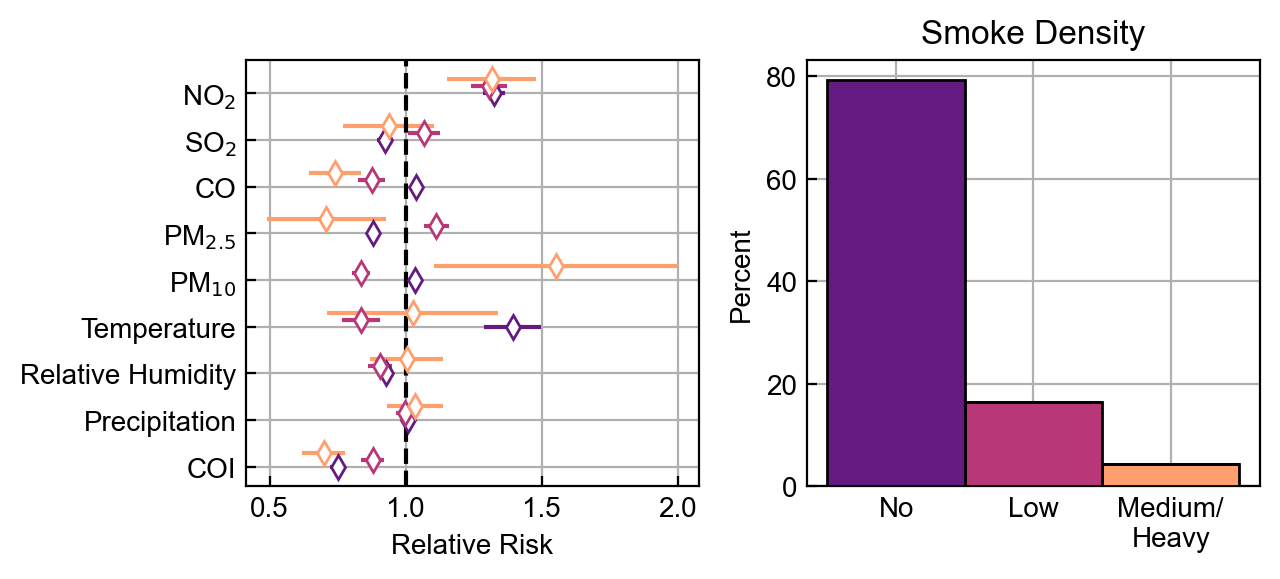

In [5]:
column = 'Smoke'
info = {
    'No Smoke': {
        'path': 'GLM/smoke/none',
        'color': plt.cm.magma(0.3),
    },
    'Low': {
        'path': 'GLM/smoke/low',
        'color': plt.cm.magma(0.5),
    },
    'Medium/\nHeavy': {
        'path': 'GLM/smoke/med_high',
        'color': plt.cm.magma(0.8),
    },
}

socio_var = 'coi'
ticks_map = {
    'NO$_2$ (ppb)': 8,
    'SO$_2$ (ppb)': 7,
    'CO (ppm)': 6,
    'PM$_{2.5}$ ($\mu$g/m$^3$)': 5,
    'PM$_{10}$ ($\mu$g/m$^3$)': 4,
    'Temperature ($^{\circ}$C)': 3,
    'Relative Humidity (%)': 2,
    'Precipitation (mm)': 1,
    'COI (%)': 0,
}

fig, ax = plt.subplots(1, 2, dpi=200, figsize=(6.5, 3.))
joint_effect_plot(ax[0], info, socio_var, ticks_map)

# Plot histogram/barplot
bins = np.arange(0, 101, 5)
plot_df = []
for label, run_info in info.items():
    if label == 'All': continue

    with open(os.path.join(os.environ['MODELS_DIR'], socio_var, run_info['path'], 'config.yaml'), 'r') as f:
        config = yaml.safe_load(f)

    column = config['datamodule']['preprocessing_config']['stratify_exposures']['column']
    col_range = config['datamodule']['preprocessing_config']['stratify_exposures']['values']
    print(column, col_range)

    df = coi.df.copy()
    df[column] *= coi.iqr[column]
    subset = df[(df[column] >= col_range[0]) & \
                (df[column] < col_range[1])]
    
        
    print(col_range, len(subset), np.ptp(subset[column]))
    plot_df.append(subset[[column]].assign(label=label))

plot_df = pd.concat(plot_df, axis=0)
sns.histplot(
    data=plot_df,
    x=column,
    hue='label',
    palette={key: info[key]['color'] for key in info},
    ax=ax[1],
    common_bins=True,
    multiple='stack',
    stat='percent',
    binwidth=1,
    legend=False,
    zorder=10,
    alpha=1.
)

ax[1].set(
    xticks=[0.5, 1.5, 2.5],
    xticklabels=['No', 'Low', 'Medium/\nHeavy'],
    xlabel=None,
    title='Smoke Density',
)
#plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.savefig(os.path.join(os.environ['MODELS_DIR'], socio_var, 'stratify_smoke.pdf'), bbox_inches='tight')